In [5]:
!pip install databento
import databento as db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\Users\USER\Desktop\MS -Thesis\Data\XNAS-20260128-UXEA6A9U6P\xnas-itch-20260126.mbp-10.dbn"

data = db.read_dbn(file_path)
df = data.to_df()

df.head()

df.columns
df.head()
df.info()

df = df.sort_values("ts_event")   #I sorted at this col because ts_event is when the event actually happened (ts_recv is when Databento received it)
df = df.dropna(subset=["bid_px_00","ask_px_00","bid_sz_00","ask_sz_00"])
df = df[df["bid_px_00"]<df["ask_px_00"]].copy()
df.head()

df["mid"] = (df["bid_px_00"] + df["ask_px_00"]) / 2
df["dmid"] = df["mid"].diff()

n_levels = 10

for l in range(n_levels):
    bid_px_col = f"bid_px_{l:02d}"
    ask_px_col = f"ask_px_{l:02d}"
    bid_sz_col = f"bid_sz_{l:02d}"
    ask_sz_col = f"ask_sz_{l:02d}"
    bid_px = df[bid_px_col].values
    ask_px = df[ask_px_col].values
    bid_sz = df[bid_sz_col].values.astype(float)
    ask_sz = df[ask_sz_col].values.astype(float)
    bid_px_prev = np.roll(bid_px, 1)
    ask_px_prev = np.roll(ask_px, 1)
    bid_sz_prev = np.roll(bid_sz, 1)
    ask_sz_prev = np.roll(ask_sz, 1)
    bid_px_prev[0] = bid_px[0]
    ask_px_prev[0] = ask_px[0]
    bid_sz_prev[0] = bid_sz[0]
    ask_sz_prev[0] = ask_sz[0]
    eb_l = np.where(
        bid_px == bid_px_prev,
        bid_sz - bid_sz_prev,
        np.where(bid_px > bid_px_prev, bid_sz, -bid_sz_prev)
    )
    ea_l = np.where(
        ask_px == ask_px_prev,
        ask_sz - ask_sz_prev,
        np.where(ask_px < ask_px_prev, ask_sz, -ask_sz_prev)
    )
    df[f"ofi_{l:02d}"] = eb_l - ea_l
    df[f"depth_{l:02d}"] = df[bid_sz_col] + df[ask_sz_col]
    df[f"inv_depth_{l:02d}"] = 1.0 / df[f"depth_{l:02d}"].replace(0, np.nan)
feature_cols = [f"ofi_{l:02d}" for l in range(n_levels)] + [f"inv_depth_{l:02d}" for l in range(n_levels)]
df = df.dropna(subset=feature_cols).copy()
for l in range(n_levels):
    df = df[df[f"depth_{l:02d}"] > 0].copy()
X_raw = df[feature_cols].to_numpy()
X_raw_small = X_raw[:50_000]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X_raw_small)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 825344 entries, 2026-01-26 09:00:00.014661840+00:00 to 2026-01-26 23:59:17.513585531+00:00
Data columns (total 73 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   ts_event       825344 non-null  datetime64[ns, UTC]
 1   rtype          825344 non-null  uint8              
 2   publisher_id   825344 non-null  uint16             
 3   instrument_id  825344 non-null  uint32             
 4   action         825344 non-null  object             
 5   side           825344 non-null  object             
 6   depth          825344 non-null  uint8              
 7   price          825344 non-null  float64            
 8   size           825344 non-null  uint32             
 9   flags          825344 non-null  uint8              
 10  ts_in_delta    825344 non-null  int32              
 11  sequence       825344 non-null  uint32             
 12  bid_px_00      82533

In [6]:
print(X.shape)
print("Number of features:", X.shape[1])
print(feature_cols)

(50000, 20)
Number of features: 20
['ofi_00', 'ofi_01', 'ofi_02', 'ofi_03', 'ofi_04', 'ofi_05', 'ofi_06', 'ofi_07', 'ofi_08', 'ofi_09', 'inv_depth_00', 'inv_depth_01', 'inv_depth_02', 'inv_depth_03', 'inv_depth_04', 'inv_depth_05', 'inv_depth_06', 'inv_depth_07', 'inv_depth_08', 'inv_depth_09']


In [7]:
save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_20d_diag_50k"

In [8]:
%run "HMM_functions.ipynb"

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
import json
import numpy as np

os.makedirs(save_dir, exist_ok=True)
K_grid = list(range(1, 10))
results, models = score_over_K_fast(
    X,
    K_grid,
    cov_type="diag",
    R=3,
    max_iter=30,
    tol=1e-4,
    eps=1e-6,
    jitter=1e-9,
    random_state=0,
    verbose=True,
)
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("K").reset_index(drop=True)
results_df["fail_rate"] = results_df["failures"] / results_df["R"]
K_aic = int(results_df.loc[results_df["AIC"].idxmin(), "K"])
K_bic = int(results_df.loc[results_df["BIC"].idxmin(), "K"])
print("AIC-best K =", K_aic)
print("BIC-best K =", K_bic)
print(results_df[["K", "loglik", "AIC", "BIC", "n_iters", "failures", "R", "fail_rate"]])

Fitting K=1, restart=1/3 ...
Fitting K=1, restart=2/3 ...
Fitting K=1, restart=3/3 ...
K=1: failures 0/3
Fitting K=2, restart=1/3 ...
Fitting K=2, restart=2/3 ...
Fitting K=2, restart=3/3 ...
K=2: failures 0/3
Fitting K=3, restart=1/3 ...
Fitting K=3, restart=2/3 ...
Fitting K=3, restart=3/3 ...
K=3: failures 0/3
Fitting K=4, restart=1/3 ...
Fitting K=4, restart=2/3 ...
Fitting K=4, restart=3/3 ...
K=4: failures 0/3
Fitting K=5, restart=1/3 ...
Fitting K=5, restart=2/3 ...
Fitting K=5, restart=3/3 ...
K=5: failures 0/3
Fitting K=6, restart=1/3 ...
Fitting K=6, restart=2/3 ...
Fitting K=6, restart=3/3 ...
K=6: failures 0/3
Fitting K=7, restart=1/3 ...
Fitting K=7, restart=2/3 ...
Fitting K=7, restart=3/3 ...
K=7: failures 0/3
Fitting K=8, restart=1/3 ...
Fitting K=8, restart=2/3 ...
Fitting K=8, restart=3/3 ...
K=8: failures 0/3
Fitting K=9, restart=1/3 ...
Fitting K=9, restart=2/3 ...
Fitting K=9, restart=3/3 ...
K=9: failures 0/3
AIC-best K = 9
BIC-best K = 9
   K        loglik       

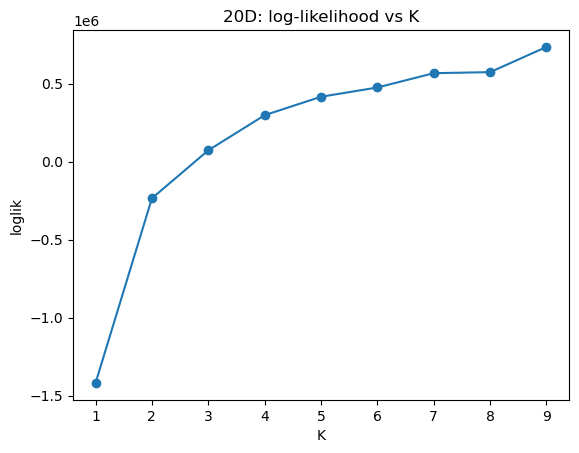

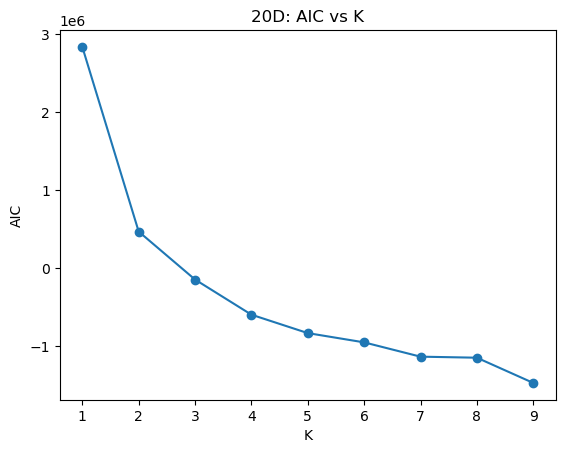

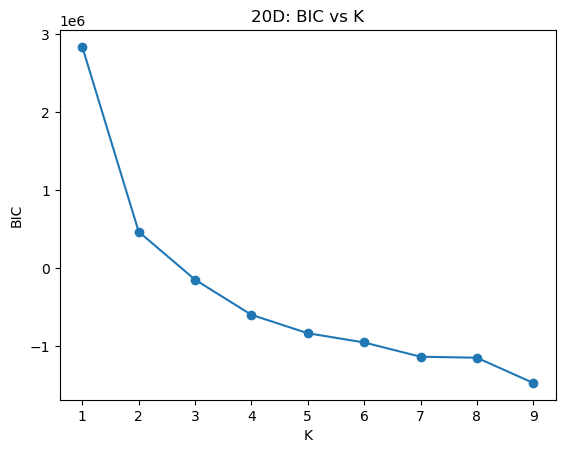

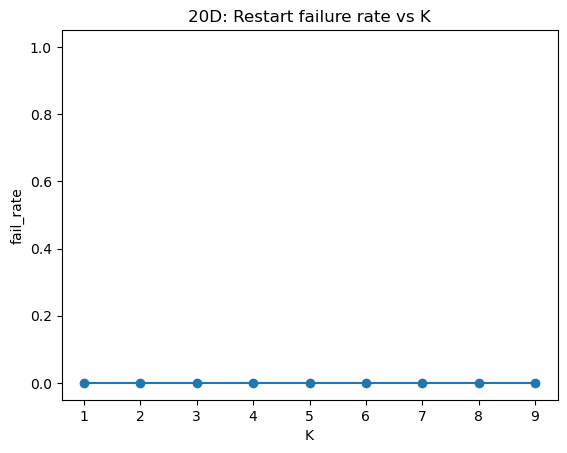

In [10]:
plt.figure()
plt.plot(results_df["K"], results_df["loglik"], marker="o")
plt.title("20D: log-likelihood vs K")
plt.xlabel("K")
plt.ylabel("loglik")
plt.savefig(os.path.join(save_dir, "loglik_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["AIC"], marker="o")
plt.title("20D: AIC vs K")
plt.xlabel("K")
plt.ylabel("AIC")
plt.savefig(os.path.join(save_dir, "AIC_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["BIC"], marker="o")
plt.title("20D: BIC vs K")
plt.xlabel("K")
plt.ylabel("BIC")
plt.savefig(os.path.join(save_dir, "BIC_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["fail_rate"], marker="o")
plt.title("20D: Restart failure rate vs K")
plt.xlabel("K")
plt.ylabel("fail_rate")
plt.ylim(-0.05, 1.05)
plt.savefig(os.path.join(save_dir, "failure_rate_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

In [11]:
results_df.to_csv(os.path.join(save_dir, "results_summary.csv"), index=False)
joblib.dump(models, os.path.join(save_dir, "models.joblib"))
np.save(os.path.join(save_dir, "X.npy"), X)
np.save(os.path.join(save_dir, "X_raw_small.npy"), X_raw_small)
joblib.dump(scaler, os.path.join(save_dir, "scaler.joblib"))
if "feature_cols" in globals():
    with open(os.path.join(save_dir, "feature_cols.json"), "w") as f:
        json.dump(feature_cols, f, indent=4)

metadata = {
    "dimension": int(X.shape[1]),
    "n_obs_used": int(X.shape[0]),
    "cov_type": "diag",
    "K_grid": [int(k) for k in K_grid],
    "R": 3,
    "max_iter": 30,
    "tol": 1e-4,
    "eps": 1e-6,
    "jitter": 1e-9,
    "random_state": 0,
    "AIC_best_K": int(K_aic),
    "BIC_best_K": int(K_bic),
}

with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("20D experiment saved to:", save_dir)

20D experiment saved to: C:\Users\USER\Desktop\MS -Thesis\Results\hmm_20d_diag_50k


In [12]:
best_K = K_bic
best_model = models[best_K]

phi, beta_bar, gamma, xi, loglik = smooth_gamma_xi_fast(
    X,
    best_model["pi"],
    best_model["A"],
    best_model["mus"],
    best_model["Sigmas"],
)

np.save(os.path.join(save_dir, f"phi_K_{best_K}.npy"), phi)
np.save(os.path.join(save_dir, f"beta_bar_K_{best_K}.npy"), beta_bar)
np.save(os.path.join(save_dir, f"gamma_K_{best_K}.npy"), gamma)
np.save(os.path.join(save_dir, f"xi_K_{best_K}.npy"), xi)
joblib.dump(best_model, os.path.join(save_dir, f"best_model_K_{best_K}.joblib"))

print(f"Saved smoothing outputs for K={best_K}")

Saved smoothing outputs for K=9


In [13]:
feature_cols = [f"ofi_{l:02d}" for l in range(10)] + [f"inv_depth_{l:02d}" for l in range(10)]

means_df = pd.DataFrame(best_model["mus"], columns=feature_cols)
means_df["state"] = np.arange(best_K)
print(means_df)

     ofi_00    ofi_01    ofi_02    ofi_03    ofi_04    ofi_05    ofi_06  \
0  0.004575  0.000417  0.001404 -0.000762  0.006079  0.014831 -0.001158   
1  0.016106  0.027007  0.008005 -0.003115  0.003424 -0.004793 -0.001582   
2 -0.004164  0.027033  0.012280  0.057189 -0.032443  0.083500  0.000952   
3 -0.003555 -0.015247 -0.019503  0.005093 -0.031349 -0.017848 -0.027593   
4  0.001252 -0.000678 -0.000301  0.001530  0.000836 -0.000170  0.000963   
5 -0.018261 -0.015309  0.023264 -0.063433  0.015602 -0.076104  0.015133   
6 -0.014666 -0.003996 -0.003315  0.001530  0.000836 -0.000170  0.000967   
7  0.010463 -0.128819 -0.077957 -0.038347  0.045471 -0.038727 -0.015627   
8  0.004575  0.000417  0.001402  0.001667  0.001899 -0.000305  0.005693   

     ofi_07    ofi_08    ofi_09  ...  inv_depth_01  inv_depth_02  \
0  0.008035  0.000230  0.004268  ...      0.561498      0.127636   
1 -0.003825 -0.003777 -0.000632  ...     -0.216659     -0.208563   
2  0.058542 -0.030368  0.036296  ...      0.0

   state            Nk  occupancy_frac  self_transition
7      7   1236.392316        0.024728         0.212858
3      3   2279.337295        0.045587         0.545021
5      5   2713.584076        0.054272         0.240888
2      2   3255.594946        0.065112         0.254386
0      0   4141.948297        0.082839         0.483403
8      8   5302.646653        0.106053         0.409711
1      1   6856.053409        0.137121         0.289282
6      6   7887.683702        0.157754         0.550124
4      4  16326.759306        0.326535         0.647166
No flagged pairs.


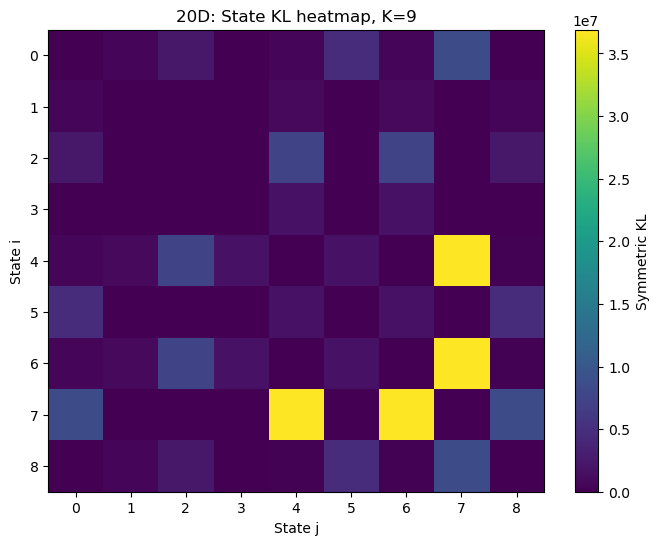

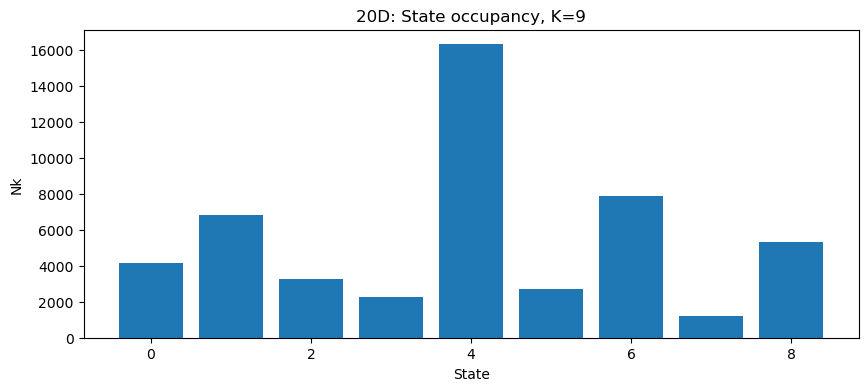

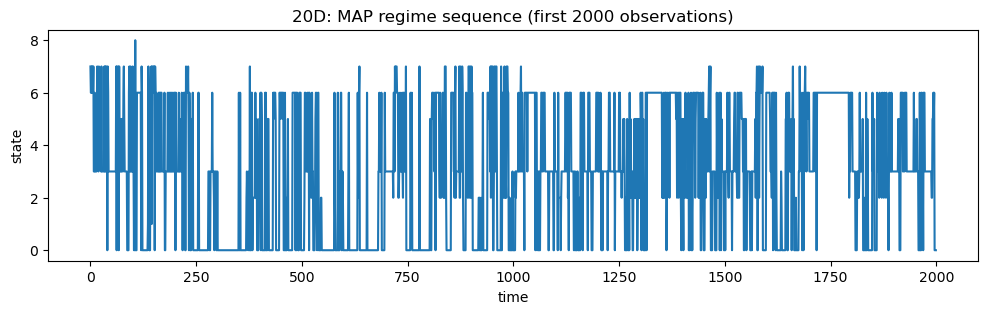

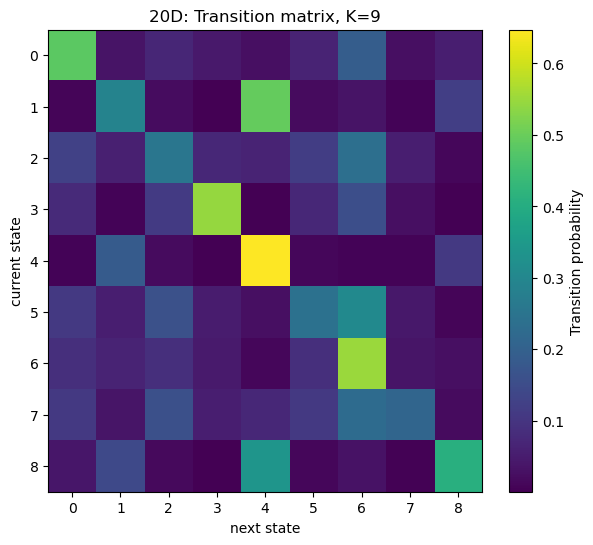

In [14]:
Nk = gamma.sum(axis=0)

occupancy_df = pd.DataFrame({
    "state": np.arange(best_K),
    "Nk": Nk,
    "occupancy_frac": Nk / gamma.shape[0],
    "self_transition": np.diag(best_model["A"]),
})

print(occupancy_df.sort_values("occupancy_frac"))

report = redundancy_report(
    best_model,
    gamma=gamma,
    cov_type="diag",
    kl_thresh=5.0,
    A_row_thresh=0.25
)

flagged_df = pd.DataFrame(report["flagged_pairs"])
print(flagged_df.head(20) if len(flagged_df) > 0 else "No flagged pairs.")

plt.figure(figsize=(8, 6))
plt.imshow(report["symKL"], aspect="auto")
plt.colorbar(label="Symmetric KL")
plt.title(f"20D: State KL heatmap, K={best_K}")
plt.xlabel("State j")
plt.ylabel("State i")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(np.arange(best_K), Nk)
plt.title(f"20D: State occupancy, K={best_K}")
plt.xlabel("State")
plt.ylabel("Nk")
plt.show()

z = np.argmax(gamma, axis=1)

plt.figure(figsize=(12, 3))
plt.plot(z[:2000])
plt.title("20D: MAP regime sequence (first 2000 observations)")
plt.xlabel("time")
plt.ylabel("state")
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(best_model["A"], aspect="auto")
plt.colorbar(label="Transition probability")
plt.title(f"20D: Transition matrix, K={best_K}")
plt.xlabel("next state")
plt.ylabel("current state")
plt.show()

Loaded old K values: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Fitting K=10, restart=1/5 ...
Fitting K=10, restart=2/5 ...
Fitting K=10, restart=3/5 ...
Fitting K=10, restart=4/5 ...
Fitting K=10, restart=5/5 ...
K=10: failures 0/5
Fitting K=11, restart=1/5 ...
Fitting K=11, restart=2/5 ...
Fitting K=11, restart=3/5 ...
Fitting K=11, restart=4/5 ...
Fitting K=11, restart=5/5 ...
K=11: failures 0/5
Fitting K=12, restart=1/5 ...
Fitting K=12, restart=2/5 ...
Fitting K=12, restart=3/5 ...
Fitting K=12, restart=4/5 ...
Fitting K=12, restart=5/5 ...
K=12: failures 0/5
Fitting K=13, restart=1/5 ...
Fitting K=13, restart=2/5 ...
Fitting K=13, restart=3/5 ...
Fitting K=13, restart=4/5 ...
Fitting K=13, restart=5/5 ...
K=13: failures 0/5
Fitting K=14, restart=1/5 ...
Fitting K=14, restart=2/5 ...
Fitting K=14, restart=3/5 ...
Fitting K=14, restart=4/5 ...
Fitting K=14, restart=5/5 ...
K=14: failures 0/5
Fitting K=15, restart=1/5 ...
Fitting K=15, restart=2/5 ...
Fitting K=15, restart=3/5 ...
Fitting K=15, re

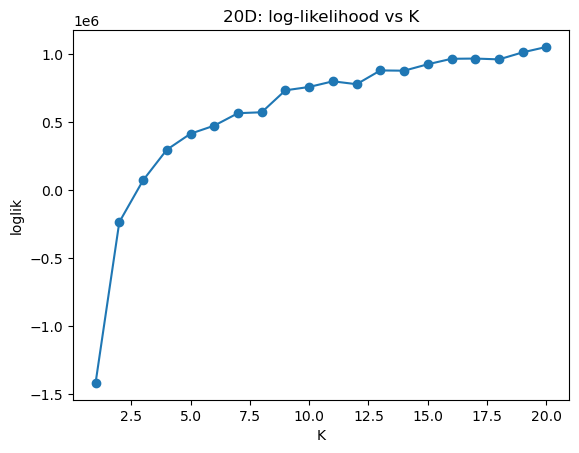

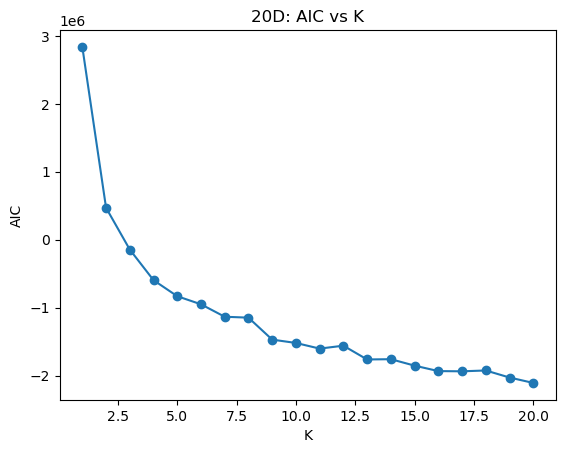

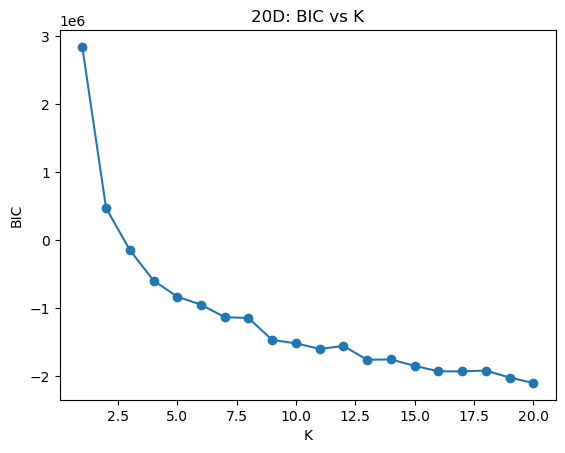

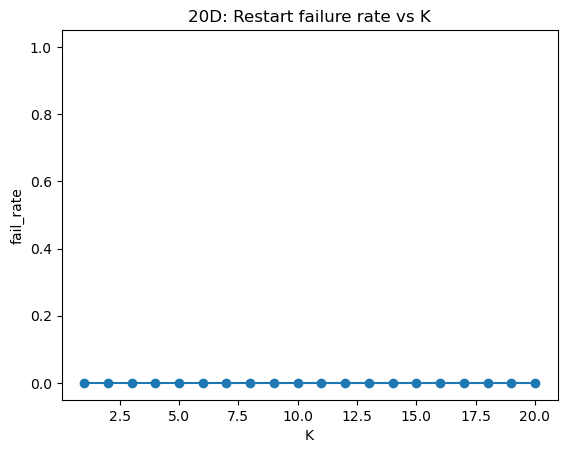

Updated 20D experiment saved to: C:\Users\USER\Desktop\MS -Thesis\Results\hmm_20d_diag_50k
Saved smoothing outputs for updated selected K=20
      ofi_00    ofi_01    ofi_02    ofi_03    ofi_04    ofi_05    ofi_06  \
0  -0.045790 -0.061936 -0.060920 -0.145734 -0.003790 -0.200088  0.038152   
1   0.004575  0.000417  0.001402  0.007714  0.006679  0.039121 -0.006729   
2   0.004575  0.000417 -0.003069  0.001388  0.000836 -0.000170  0.000963   
3  -0.026742 -0.086984 -0.068765 -0.010764  0.022960 -0.097816  0.005665   
4  -0.072524 -0.211659 -0.147305 -0.137476 -0.146422 -0.146532 -0.344744   
5   0.448241  0.656456  0.620111  0.586735  0.617609  0.577736  0.506343   
6  -0.003521 -0.022963 -0.080050 -0.027852 -0.077666 -0.042180 -0.133012   
7   0.011427 -0.016243  0.061701  0.049168 -0.062858  0.039924  0.228647   
8   0.010328 -0.025837 -0.007983  0.051754 -0.002596 -0.039134  0.013888   
9  -0.421658 -0.610409 -0.587292 -0.582630 -0.607698 -0.574401 -0.503597   
10  0.079909 -0.035556 

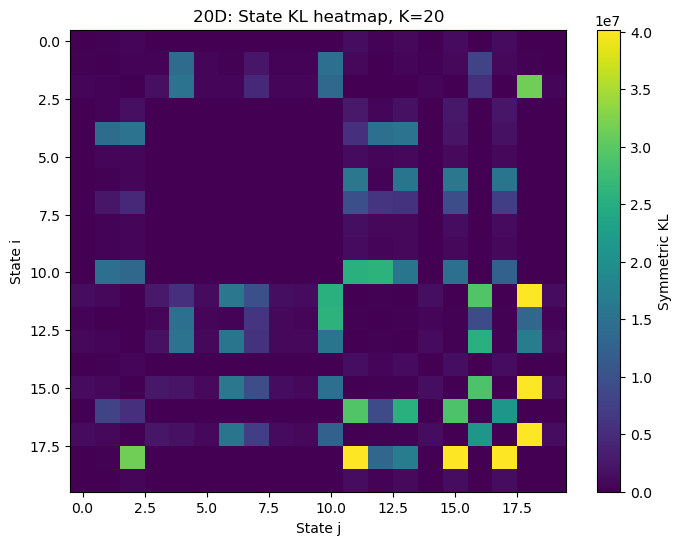

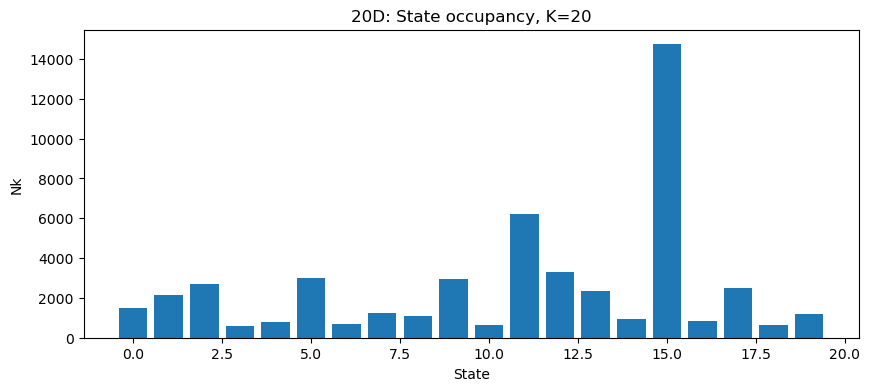

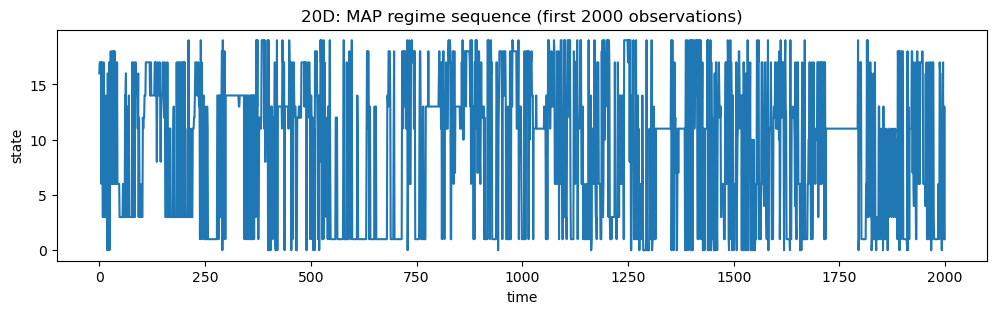

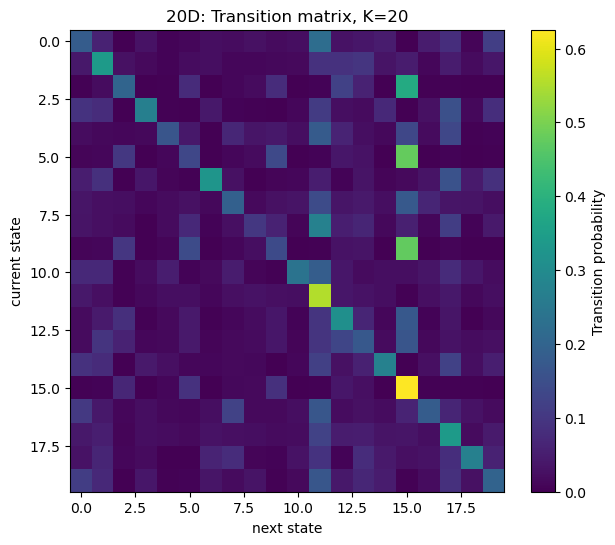

Extended 20D study complete.


In [3]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_20d_diag_50k"
%run "HMM_functions.ipynb"

results_df_old = pd.read_csv(os.path.join(save_dir, "results_summary.csv"))
models_old = joblib.load(os.path.join(save_dir, "models.joblib"))
X = np.load(os.path.join(save_dir, "X.npy"))
X_raw_small = np.load(os.path.join(save_dir, "X_raw_small.npy"))
scaler = joblib.load(os.path.join(save_dir, "scaler.joblib"))

feature_cols_path = os.path.join(save_dir, "feature_cols.json")
if os.path.exists(feature_cols_path):
    with open(feature_cols_path, "r") as f:
        feature_cols = json.load(f)

print("Loaded old K values:", sorted(results_df_old["K"].tolist()))

K_grid_new = list(range(10, 21))

results_new, models_new = score_over_K_fast(
    X,
    K_grid_new,
    cov_type="diag",
    R=5,
    max_iter=50,
    tol=1e-4,
    eps=1e-6,
    jitter=1e-9,
    random_state=0,
    verbose=True,
)

results_df_new = pd.DataFrame(results_new)
results_df_new = results_df_new.sort_values("K").reset_index(drop=True)
results_df_new["fail_rate"] = results_df_new["failures"] / results_df_new["R"]
results_df_all = pd.concat([results_df_old, results_df_new], ignore_index=True)
results_df_all = results_df_all.sort_values("K").reset_index(drop=True)
results_df_all = results_df_all.drop_duplicates(subset=["K"], keep="last").reset_index(drop=True)
models_all = dict(models_old)
models_all.update(models_new)
K_aic = int(results_df_all.loc[results_df_all["AIC"].idxmin(), "K"])
K_bic = int(results_df_all.loc[results_df_all["BIC"].idxmin(), "K"])

print("Updated AIC-best K =", K_aic)
print("Updated BIC-best K =", K_bic)
print(results_df_all[["K", "loglik", "AIC", "BIC", "n_iters", "failures", "R", "fail_rate"]])

plt.figure()
plt.plot(results_df_all["K"], results_df_all["loglik"], marker="o")
plt.title("20D: log-likelihood vs K")
plt.xlabel("K")
plt.ylabel("loglik")
plt.savefig(os.path.join(save_dir, "loglik_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df_all["K"], results_df_all["AIC"], marker="o")
plt.title("20D: AIC vs K")
plt.xlabel("K")
plt.ylabel("AIC")
plt.savefig(os.path.join(save_dir, "AIC_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df_all["K"], results_df_all["BIC"], marker="o")
plt.title("20D: BIC vs K")
plt.xlabel("K")
plt.ylabel("BIC")
plt.savefig(os.path.join(save_dir, "BIC_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(results_df_all["K"], results_df_all["fail_rate"], marker="o")
plt.title("20D: Restart failure rate vs K")
plt.xlabel("K")
plt.ylabel("fail_rate")
plt.ylim(-0.05, 1.05)
plt.savefig(os.path.join(save_dir, "failure_rate_vs_K.png"), dpi=300, bbox_inches="tight")
plt.show()

results_df_all.to_csv(os.path.join(save_dir, "results_summary.csv"), index=False)
joblib.dump(models_all, os.path.join(save_dir, "models.joblib"))

metadata = {
    "dimension": int(X.shape[1]),
    "n_obs_used": int(X.shape[0]),
    "cov_type": "diag",
    "K_grid": [int(k) for k in results_df_all["K"].tolist()],
    "R_old": 3,
    "max_iter_old": 30,
    "R_new": 5,
    "max_iter_new": 50,
    "tol": 1e-4,
    "eps": 1e-6,
    "jitter": 1e-9,
    "random_state": 0,
    "AIC_best_K": int(K_aic),
    "BIC_best_K": int(K_bic),
}

with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("Updated 20D experiment saved to:", save_dir)

best_K = K_bic
best_model = models_all[best_K]

phi, beta_bar, gamma, xi, loglik = smooth_gamma_xi_fast(
    X,
    best_model["pi"],
    best_model["A"],
    best_model["mus"],
    best_model["Sigmas"],
)

np.save(os.path.join(save_dir, f"phi_K_{best_K}.npy"), phi)
np.save(os.path.join(save_dir, f"beta_bar_K_{best_K}.npy"), beta_bar)
np.save(os.path.join(save_dir, f"gamma_K_{best_K}.npy"), gamma)
np.save(os.path.join(save_dir, f"xi_K_{best_K}.npy"), xi)
joblib.dump(best_model, os.path.join(save_dir, f"best_model_K_{best_K}.joblib"))

print(f"Saved smoothing outputs for updated selected K={best_K}")

if "feature_cols" not in globals():
    feature_cols = [f"ofi_{l:02d}" for l in range(10)] + [f"inv_depth_{l:02d}" for l in range(10)]

means_df = pd.DataFrame(best_model["mus"], columns=feature_cols)
means_df["state"] = np.arange(best_K)
print(means_df)

Nk = gamma.sum(axis=0)
occupancy_df = pd.DataFrame({
    "state": np.arange(best_K),
    "Nk": Nk,
    "occupancy_frac": Nk / gamma.shape[0],
    "self_transition": np.diag(best_model["A"]),
})
print(occupancy_df.sort_values("occupancy_frac"))

report = redundancy_report(
    best_model,
    gamma=gamma,
    cov_type="diag",
    kl_thresh=5.0,
    A_row_thresh=0.25
)

flagged_df = pd.DataFrame(report["flagged_pairs"])
print(flagged_df.head(20) if len(flagged_df) > 0 else "No flagged pairs.")

plt.figure(figsize=(8, 6))
plt.imshow(report["symKL"], aspect="auto")
plt.colorbar(label="Symmetric KL")
plt.title(f"20D: State KL heatmap, K={best_K}")
plt.xlabel("State j")
plt.ylabel("State i")
plt.savefig(os.path.join(save_dir, f"KL_heatmap_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(np.arange(best_K), Nk)
plt.title(f"20D: State occupancy, K={best_K}")
plt.xlabel("State")
plt.ylabel("Nk")
plt.savefig(os.path.join(save_dir, f"occupancy_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

z = np.argmax(gamma, axis=1)
plt.figure(figsize=(12, 3))
plt.plot(z[:2000])
plt.title("20D: MAP regime sequence (first 2000 observations)")
plt.xlabel("time")
plt.ylabel("state")
plt.savefig(os.path.join(save_dir, f"regime_sequence_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(best_model["A"], aspect="auto")
plt.colorbar(label="Transition probability")
plt.title(f"20D: Transition matrix, K={best_K}")
plt.xlabel("next state")
plt.ylabel("current state")
plt.savefig(os.path.join(save_dir, f"transition_matrix_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

means_df.to_csv(os.path.join(save_dir, f"state_means_K_{best_K}.csv"), index=False)
occupancy_df.to_csv(os.path.join(save_dir, f"state_occupancy_K_{best_K}.csv"), index=False)
flagged_df.to_csv(os.path.join(save_dir, f"redundancy_pairs_K_{best_K}.csv"), index=False)
pd.DataFrame(report["symKL"]).to_csv(os.path.join(save_dir, f"symKL_matrix_K_{best_K}.csv"), index=False)

print("Extended 20D study complete.")